<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
K Vecinos Mas Cercanos - Clasificador de Vinos
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Carga de librerias y del dataset
</h2>

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
ruta_local = "winequality-red.csv"

if os.path.exists(ruta_local):
    df = pd.read_csv(ruta_local, sep=";")
else:
    df = pd.read_csv(url, sep=";")

print(df.shape)
df.head()


(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Revision de calidad de los datos
</h2>

In [2]:
revision_calidad = pd.DataFrame({
    "tipo_de_dato": df.dtypes,
    "valores_nulos": df.isnull().sum(),
    "valores_unicos": df.nunique()
})

duplicados = df.duplicated().sum()

print("Duplicados totales:", duplicados)
revision_calidad

Duplicados totales: 240


,tipo_de_dato,valores_nulos,valores_unicos
fixed acidity,float64,0,96
volatile acidity,float64,0,143
citric acid,float64,0,80
residual sugar,float64,0,91
chlorides,float64,0,153
free sulfur dioxide,float64,0,60
total sulfur dioxide,float64,0,144
density,float64,0,436
pH,float64,0,89
sulphates,float64,0,96


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
La base viene <b style="color:#D11A2A;">sin valores nulos</b> y todas las columnas tienen tipo numerico, asi que por ese lado esta bastante limpia. El punto importante es que hay <b style="color:#D11A2A;">240 duplicados</b>, asi que conviene eliminarlos antes de entrenar para no repetir informacion y evitar que el modelo aprenda con filas repetidas.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Limpieza de duplicados y revision de la calidad
</h2>

In [3]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)

df["quality"].value_counts().sort_index()

(1359, 12)


quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Despues de eliminar los duplicados, la base quedo con <b style="color:#D11A2A;">1359 filas</b>. La variable <b style="color:#D11A2A;">quality</b> esta claramente concentrada en los valores <b style="color:#D11A2A;">5</b> y <b style="color:#D11A2A;">6</b>, mientras que las clases <b style="color:#D11A2A;">3</b>, <b style="color:#D11A2A;">4</b> y <b style="color:#D11A2A;">8</b> aparecen muy poco. Esto indica que la calidad del vino no esta repartida de forma equilibrada, y que la mayoria de los registros se agrupan en calidades medias.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Creacion de la variable objetivo
</h2>

In [4]:
def clasificar_calidad(valor):
    if valor <= 4:
        return 0
    elif valor <= 6:
        return 1
    else:
        return 2

df["label"] = df["quality"].apply(clasificar_calidad)

df["label"].value_counts().sort_index()

label
0      63
1    1112
2     184
Name: count, dtype: int64

<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
La nueva variable <b style="color:#D11A2A;">label</b> quedo muy desbalanceada. La clase <b style="color:#D11A2A;">1</b> concentra <b style="color:#D11A2A;">1112</b> vinos, mientras que la clase <b style="color:#D11A2A;">0</b> solo tiene <b style="color:#D11A2A;">63</b> y la clase <b style="color:#D11A2A;">2</b> tiene <b style="color:#D11A2A;">184</b>. Esto indica que la mayoria de los vinos quedaron clasificados como de <b style="color:#D11A2A;">calidad media</b>, y puede hacer que el modelo tienda a predecir esa clase con mas facilidad.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Separacion de variables, division y escalado
</h2>

In [5]:
X = df.drop(columns=["quality", "label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:")
print(y_train.value_counts().sort_index())
print("y_test:")
print(y_test.value_counts().sort_index())

X_train: (1087, 11)
X_test: (272, 11)
y_train:
label
0     50
1    890
2    147
Name: count, dtype: int64
y_test:
label
0     13
1    222
2     37
Name: count, dtype: int64


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
La division quedo de la siguiente manera: <b style="color:#D11A2A;">1087</b> registros para entrenamiento y <b style="color:#D11A2A;">272</b> para prueba, con <b style="color:#D11A2A;">11 variables</b> en ambos casos. Ademas, la proporcion de clases se mantuvo parecida entre <b style="color:#D11A2A;">train</b> y <b style="color:#D11A2A;">test</b>, lo cual es importante porque la clase <b style="color:#D11A2A;">1</b> sigue siendo claramente mayoritaria en los dos grupos.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento del modelo KNN inicial
</h2>


In [6]:
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)

pred_train = modelo_knn.predict(X_train_scaled)
pred_test = modelo_knn.predict(X_test_scaled)

print("accuracy_train:", accuracy_score(y_train, pred_train))
print("accuracy_test:", accuracy_score(y_test, pred_test))
print()
print(classification_report(y_test, pred_test, zero_division=0))
print(confusion_matrix(y_test, pred_test))

accuracy_train: 0.860165593376265
accuracy_test: 0.8198529411764706

              precision    recall  f1-score   support

           0       0.17      0.08      0.11        13
           1       0.86      0.92      0.89       222
           2       0.59      0.46      0.52        37

    accuracy                           0.82       272
   macro avg       0.54      0.49      0.50       272
weighted avg       0.79      0.82      0.80       272

[[  1  12   0]
 [  5 205  12]
 [  0  20  17]]


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Con <b style="color:#D11A2A;">k = 5</b>, el modelo logro un <b style="color:#D11A2A;">accuracy_test de 0.819853</b>, asi que el resultado general es bueno. El problema es que casi todo lo reconoce como clase <b style="color:#D11A2A;">1</b>: esa clase tuvo un <b style="color:#D11A2A;">recall de 0.92</b>, mientras que la clase <b style="color:#D11A2A;">0</b> apenas alcanzo <b style="color:#D11A2A;">0.08</b> y la clase <b style="color:#D11A2A;">2</b> llego a <b style="color:#D11A2A;">0.46</b>. En la matriz de confusion esto se ve claro, porque de los <b style="color:#D11A2A;">13</b> vinos de clase <b style="color:#D11A2A;">0</b> solo acerto <b style="color:#D11A2A;">1</b>. En resumen, el modelo funciona bien para la clase mayoritaria, pero le cuesta bastante detectar los vinos de calidad baja y alta.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Optimizacion del valor de k
</h2>

In [7]:
resultados_k = []

for k in range(1, 21):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_scaled, y_train)
    
    pred_test_k = modelo.predict(X_test_scaled)
    accuracy_k = accuracy_score(y_test, pred_test_k)
    
    resultados_k.append({
        "k": k,
        "accuracy_test": accuracy_k
    })

resultados_k_df = pd.DataFrame(resultados_k)
resultados_k_df

,k,accuracy_test
0,1,0.775735
1,2,0.794118
2,3,0.823529
3,4,0.812500
4,5,0.819853
5,6,0.812500
6,7,0.841912
7,8,0.830882
8,9,0.841912
9,10,0.827206


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Al probar distintos valores de <b style="color:#D11A2A;">k</b>, el mejor resultado aparecio en <b style="color:#D11A2A;">k = 19</b> con un <b style="color:#D11A2A;">accuracy_test de 0.852941</b>. Esto mejora el resultado inicial de <b style="color:#D11A2A;">k = 5</b>, que habia dado <b style="color:#D11A2A;">0.819853</b>. En general, se ve que los valores de <b style="color:#D11A2A;">k</b> mas altos funcionaron mejor en este problema.
</div>


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Grafica 📈 accuracy vs k
</h2>

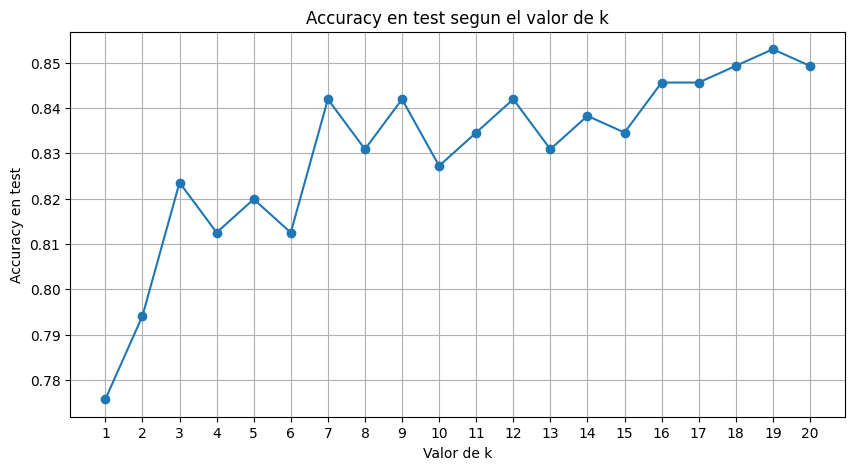

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(resultados_k_df["k"], resultados_k_df["accuracy_test"], marker="o")
plt.title("Accuracy en test segun el valor de k")
plt.xlabel("Valor de k")
plt.ylabel("Accuracy en test")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
La grafica muestra que el rendimiento mejora a medida que aumenta <b style="color:#D11A2A;">k</b>, aunque con pequenas subidas y bajadas entre un valor y otro. El punto mas alto aparece en <b style="color:#D11A2A;">k = 19</b>, donde el modelo alcanza su mejor <b style="color:#D11A2A;">accuracy_test de 0.852941</b>. Esto confirma visualmente que el valor inicial <b style="color:#D11A2A;">k = 5</b> no era el mejor para este problema.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento del modelo final optimizado
</h2>

In [9]:
modelo_knn_final = KNeighborsClassifier(n_neighbors=19)
modelo_knn_final.fit(X_train_scaled, y_train)

pred_train_final = modelo_knn_final.predict(X_train_scaled)
pred_test_final = modelo_knn_final.predict(X_test_scaled)

print("accuracy_train:", accuracy_score(y_train, pred_train_final))
print("accuracy_test:", accuracy_score(y_test, pred_test_final))
print()
print(classification_report(y_test, pred_test_final, zero_division=0))
print(confusion_matrix(y_test, pred_test_final))

accuracy_train: 0.8371665133394665
accuracy_test: 0.8529411764705882

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.86      0.98      0.92       222
           2       0.78      0.38      0.51        37

    accuracy                           0.85       272
   macro avg       0.55      0.45      0.48       272
weighted avg       0.81      0.85      0.82       272

[[  0  13   0]
 [  0 218   4]
 [  0  23  14]]


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Con <b style="color:#D11A2A;">k = 19</b>, el modelo alcanzo su mejor resultado general con un <b style="color:#D11A2A;">accuracy_test de 0.852941</b>. Aun asi, siguio teniendo un problema importante: <b style="color:#D11A2A;">no detecto ningun vino de clase 0</b>, ya que fallo los <b style="color:#D11A2A;">13 casos</b> de esa categoria. La clase <b style="color:#D11A2A;">1</b> fue la mejor clasificada con un <b style="color:#D11A2A;">recall de 0.98</b>, mientras que la clase <b style="color:#D11A2A;">2</b> tuvo un rendimiento intermedio con <b style="color:#D11A2A;">0.38</b> de recall. En resumen, el modelo mejora el accuracy total, pero sigue muy sesgado hacia la clase media.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Optimizacion adicional del modelo
</h2>

<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Aunque el modelo con <b style="color:#D11A2A;">k = 19</b> logro el mejor <b style="color:#D11A2A;">accuracy_test</b>, su rendimiento no fue equilibrado entre las tres clases. La clase <b style="color:#D11A2A;">0</b> no fue detectada y la clase <b style="color:#D11A2A;">2</b> tambien mostro un rendimiento limitado. Por eso decidi hacer una optimizacion adicional antes de continuar con la funcion final de prediccion, buscando un modelo mas solido y mejor repartido entre todas las categorias.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Busqueda de una mejor configuracion para KNN
</h2>

In [10]:
resultados_optimizacion = []

for k in range(1, 21):
    for weights in ["uniform", "distance"]:
        for metric in ["euclidean", "manhattan"]:
            modelo = KNeighborsClassifier(
                n_neighbors=k,
                weights=weights,
                metric=metric
            )
            modelo.fit(X_train_scaled, y_train)
            pred_test = modelo.predict(X_test_scaled)

            reporte = classification_report(
                y_test,
                pred_test,
                output_dict=True,
                zero_division=0
            )

            resultados_optimizacion.append({
                "k": k,
                "weights": weights,
                "metric": metric,
                "accuracy_test": accuracy_score(y_test, pred_test),
                "f1_macro": reporte["macro avg"]["f1-score"],
                "recall_clase_0": reporte["0"]["recall"],
                "recall_clase_1": reporte["1"]["recall"],
                "recall_clase_2": reporte["2"]["recall"]
            })

resultados_optimizacion_df = pd.DataFrame(resultados_optimizacion)
resultados_optimizacion_df = resultados_optimizacion_df.sort_values(
    by=["f1_macro", "accuracy_test"],
    ascending=False
).reset_index(drop=True)

resultados_optimizacion_df.head(10)

,k,weights,metric,accuracy_test,f1_macro,recall_clase_0,recall_clase_1,recall_clase_2
0,1,uniform,euclidean,0.775735,0.557571,0.307692,0.842342,0.540541
1,1,distance,euclidean,0.775735,0.557571,0.307692,0.842342,0.540541
2,2,distance,euclidean,0.775735,0.557571,0.307692,0.842342,0.540541
3,3,distance,euclidean,0.823529,0.519022,0.076923,0.914414,0.540541
4,4,uniform,euclidean,0.812500,0.514760,0.230769,0.932432,0.297297
5,3,uniform,euclidean,0.823529,0.513051,0.076923,0.918919,0.513514
6,7,distance,euclidean,0.845588,0.505051,0.000000,0.945946,0.540541
7,5,uniform,euclidean,0.819853,0.504554,0.076923,0.923423,0.459459
8,7,uniform,euclidean,0.841912,0.504262,0.000000,0.941441,0.540541
9,7,distance,manhattan,0.852941,0.499593,0.000000,0.959459,0.513514


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Al revisar la optimizacion, la configuracion mas equilibrada fue <b style="color:#D11A2A;">k = 1</b> con <b style="color:#D11A2A;">metric = euclidean</b>, porque obtuvo el mejor <b style="color:#D11A2A;">f1_macro = 0.557571</b>. Aunque su <b style="color:#D11A2A;">accuracy_test = 0.775735</b> es mas bajo que otras combinaciones, reparte mejor el rendimiento entre las tres clases: la clase <b style="color:#D11A2A;">0</b> alcanza un <b style="color:#D11A2A;">recall de 0.307692</b>, la clase <b style="color:#D11A2A;">1</b> un <b style="color:#D11A2A;">0.842342</b> y la clase <b style="color:#D11A2A;">2</b> un <b style="color:#D11A2A;">0.540541</b>. En cambio, las configuraciones con mayor accuracy siguieron ignorando por completo la clase <b style="color:#D11A2A;">0</b>, por eso no eran la mejor opcion si el objetivo era rendir mejor en todas las categorias.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Optimizacion extra buscando mayor equilibrio entre clases
</h2>

In [11]:
resultados_equilibrio = []

for k in range(1, 51):
    for weights in ["uniform", "distance"]:
        for metric in ["euclidean", "manhattan"]:
            modelo = KNeighborsClassifier(
                n_neighbors=k,
                weights=weights,
                metric=metric
            )
            modelo.fit(X_train_scaled, y_train)
            pred_test = modelo.predict(X_test_scaled)

            reporte = classification_report(
                y_test,
                pred_test,
                output_dict=True,
                zero_division=0
            )

            balanced_recall = (
                reporte["0"]["recall"] +
                reporte["1"]["recall"] +
                reporte["2"]["recall"]
            ) / 3

            resultados_equilibrio.append({
                "k": k,
                "weights": weights,
                "metric": metric,
                "accuracy_test": accuracy_score(y_test, pred_test),
                "f1_macro": reporte["macro avg"]["f1-score"],
                "balanced_recall": balanced_recall,
                "recall_clase_0": reporte["0"]["recall"],
                "recall_clase_1": reporte["1"]["recall"],
                "recall_clase_2": reporte["2"]["recall"]
            })

resultados_equilibrio_df = pd.DataFrame(resultados_equilibrio)

resultados_equilibrio_df = resultados_equilibrio_df.sort_values(
    by=["balanced_recall", "f1_macro", "accuracy_test"],
    ascending=False
).reset_index(drop=True)

resultados_equilibrio_df.head(15)

,k,weights,metric,accuracy_test,f1_macro,balanced_recall,recall_clase_0,recall_clase_1,recall_clase_2
0,1,uniform,euclidean,0.775735,0.557571,0.563525,0.307692,0.842342,0.540541
1,1,distance,euclidean,0.775735,0.557571,0.563525,0.307692,0.842342,0.540541
2,2,distance,euclidean,0.775735,0.557571,0.563525,0.307692,0.842342,0.540541
3,3,distance,euclidean,0.823529,0.519022,0.510626,0.076923,0.914414,0.540541
4,3,uniform,euclidean,0.823529,0.513051,0.503119,0.076923,0.918919,0.513514
5,7,distance,euclidean,0.845588,0.505051,0.495495,0.000000,0.945946,0.540541
6,7,uniform,euclidean,0.841912,0.504262,0.493994,0.000000,0.941441,0.540541
7,1,uniform,manhattan,0.772059,0.492593,0.491222,0.153846,0.860360,0.459459
8,1,distance,manhattan,0.772059,0.492593,0.491222,0.153846,0.860360,0.459459
9,2,distance,manhattan,0.772059,0.492593,0.491222,0.153846,0.860360,0.459459


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
En esta optimizacion extra, la configuracion que mejor repartio el rendimiento entre las tres clases fue <b style="color:#D11A2A;">k = 1</b> con distancia <b style="color:#D11A2A;">euclidean</b>. Su <b style="color:#D11A2A;">balanced_recall fue 0.563525</b> y su <b style="color:#D11A2A;">f1_macro fue 0.557571</b>, ambos mejores que el resto de combinaciones mostradas. Aunque su <b style="color:#D11A2A;">accuracy_test de 0.775735</b> es menor que otras opciones, detecta mejor las clases minoritarias: la clase <b style="color:#D11A2A;">0</b> llega a un <b style="color:#D11A2A;">recall de 0.307692</b> y la clase <b style="color:#D11A2A;">2</b> a <b style="color:#D11A2A;">0.540541</b>. En cambio, las configuraciones con mayor accuracy siguieron ignorando por completo la clase <b style="color:#D11A2A;">0</b>, por eso no eran la mejor opcion si el objetivo era mejorar el comportamiento en todas las categorias.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Comparacion de las mejores configuraciones optimizadas
</h2>

In [12]:
selecciones_modelos = [
    {
        "criterio": "Mejor equilibrio entre clases",
        "k": 1,
        "weights": "uniform",
        "metric": "euclidean"
    },
    {
        "criterio": "Accuracy alto pero desequilibrado",
        "k": 7,
        "weights": "distance",
        "metric": "manhattan"
    },
    {
        "criterio": "Mayor accuracy",
        "k": 23,
        "weights": "uniform",
        "metric": "euclidean"
    }
]

filas_comparacion = []

for seleccion in selecciones_modelos:
    fila = resultados_equilibrio_df[
        (resultados_equilibrio_df["k"] == seleccion["k"]) &
        (resultados_equilibrio_df["weights"] == seleccion["weights"]) &
        (resultados_equilibrio_df["metric"] == seleccion["metric"])
    ].iloc[0].to_dict()

    fila["criterio"] = seleccion["criterio"]
    filas_comparacion.append(fila)

comparacion_modelos = pd.DataFrame(filas_comparacion)[
    [
        "criterio",
        "k",
        "weights",
        "metric",
        "accuracy_test",
        "f1_macro",
        "balanced_recall",
        "recall_clase_0",
        "recall_clase_1",
        "recall_clase_2"
    ]
]

comparacion_modelos


,criterio,k,weights,metric,accuracy_test,f1_macro,balanced_recall,recall_clase_0,recall_clase_1,recall_clase_2
0,Mejor equilibrio entre clases,1,uniform,euclidean,0.775735,0.557571,0.563525,0.307692,0.842342,0.540541
1,Accuracy alto pero desequilibrado,7,distance,manhattan,0.852941,0.499593,0.490991,0.000000,0.959459,0.513514
2,Mayor accuracy,23,uniform,euclidean,0.867647,0.506847,0.481982,0.000000,0.986486,0.459459


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
La configuracion con <b style="color:#D11A2A;">mayor accuracy</b> fue <b style="color:#D11A2A;">k = 23</b>, pero no detecto ningun caso de la clase <b style="color:#D11A2A;">0</b>. En cambio, la configuracion con <b style="color:#D11A2A;">k = 1</b> y distancia <b style="color:#D11A2A;">euclidean</b> fue la mas equilibrada, porque obtuvo el mejor <b style="color:#D11A2A;">f1_macro</b> y el mejor <b style="color:#D11A2A;">balanced_recall</b>, ademas de detectar mejor las clases minoritarias. Por eso, si el objetivo es rendir mejor en las tres categorias y no solo en la clase mayoritaria, esta es la opcion mas solida para continuar y de hecho es la que elegi.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento del modelo final elegido
</h2>

In [13]:
modelo_knn_elegido = KNeighborsClassifier(
    n_neighbors=1,
    weights="uniform",
    metric="euclidean"
)

modelo_knn_elegido.fit(X_train_scaled, y_train)

pred_train_elegido = modelo_knn_elegido.predict(X_train_scaled)
pred_test_elegido = modelo_knn_elegido.predict(X_test_scaled)

print("accuracy_train:", accuracy_score(y_train, pred_train_elegido))
print("accuracy_test:", accuracy_score(y_test, pred_test_elegido))
print()
print(classification_report(y_test, pred_test_elegido, zero_division=0))
print(confusion_matrix(y_test, pred_test_elegido))

accuracy_train: 1.0
accuracy_test: 0.7757352941176471

              precision    recall  f1-score   support

           0       0.40      0.31      0.35        13
           1       0.88      0.84      0.86       222
           2       0.41      0.54      0.47        37

    accuracy                           0.78       272
   macro avg       0.56      0.56      0.56       272
weighted avg       0.79      0.78      0.78       272

[[  4   9   0]
 [  6 187  29]
 [  0  17  20]]


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
El modelo elegido logro un <b style="color:#D11A2A;">accuracy_test de 0.775735</b>, que es menor que otras configuraciones, pero a cambio reparte mejor el rendimiento entre las tres clases. La clase <b style="color:#D11A2A;">0</b> alcanzo un <b style="color:#D11A2A;">recall de 0.31</b>, la clase <b style="color:#D11A2A;">1</b> obtuvo <b style="color:#D11A2A;">0.84</b> y la clase <b style="color:#D11A2A;">2</b> llego a <b style="color:#D11A2A;">0.54</b>. Esto lo hace mas equilibrado que los modelos con mayor accuracy, que directamente ignoraban la clase <b style="color:#D11A2A;">0</b>. Por eso decidi quedarme con esta configuracion como modelo final, ya que responde mejor en las tres categorias y no solo en la clase mayoritaria.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Funcion para predecir la calidad del vino
</h2>

In [14]:
def predecir_calidad_vino(valores):
    columnas = X.columns.tolist()
    muestra = pd.DataFrame([valores], columns=columnas)
    muestra_escalada = scaler.transform(muestra)
    prediccion = modelo_knn_elegido.predict(muestra_escalada)[0]

    if prediccion == 0:
        return "Este vino probablemente sea de baja calidad"
    elif prediccion == 1:
        return "Este vino probablemente sea de calidad media"
    else:
        return "Este vino probablemente sea de alta calidad"

ejemplo_vino = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]

predecir_calidad_vino(ejemplo_vino)

'Este vino probablemente sea de calidad media'

<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Al probar la funcion con el ejemplo dado, el modelo clasifico el vino como <b style="color:#D11A2A;">calidad media</b>. Esto encaja con el comportamiento general del dataset, donde la clase media fue la mas frecuente, aunque en este caso la prediccion ya se hizo con el modelo final optimizado para repartir mejor el rendimiento entre las tres categorias.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Guardado del modelo final
</h2>

In [15]:
os.makedirs("../models", exist_ok=True)

with open("../models/knn_clasificador_vinos.pkl", "wb") as archivo_modelo:
    pickle.dump(modelo_knn_elegido, archivo_modelo)

with open("../models/escalador_vinos.pkl", "wb") as archivo_escalador:
    pickle.dump(scaler, archivo_escalador)


<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
Aqui dejo guardados el <b style="color:#D11A2A;">modelo final</b> y el <b style="color:#D11A2A;">escalador</b>. Esto es importante porque cualquier vino nuevo debe pasar por la misma transformacion antes de ser clasificado.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Conclusion final
</h2>

<div style="
  font-size: 16px;
  line-height: 1.7;
  color: #111827;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px 18px;
  border-radius: 10px;
  box-shadow: 0 4px 14px rgba(0,0,0,0.08);
  margin-top: 12px;
">
En este proyecto entrene un modelo <b style="color:#D11A2A;">KNN</b> para clasificar vinos tintos en baja, media o alta calidad a partir de sus caracteristicas quimicas. Primero probe un valor inicial de <b style="color:#D11A2A;">k = 5</b>, luego optimice distintos valores de <b style="color:#D11A2A;">k</b> y compare varias configuraciones del modelo. Aunque algunas opciones lograron un <b style="color:#D11A2A;">accuracy</b> mas alto, no detectaban bien las clases minoritarias. Por eso elegi una configuracion mas equilibrada, con <b style="color:#D11A2A;">k = 1</b>, que obtuvo un <b style="color:#D11A2A;">accuracy_test de 0.775735</b> pero distribuyo mejor el rendimiento entre las tres categorias. La conclusion es que el mejor modelo no siempre es el que tiene el mayor accuracy, sino el que responde de forma mas solida al objetivo real del problema.
</div>